In [2]:
import pandas as pd
import numpy as np
from typing import List, Tuple, Dict, Optional
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

- X: 特徵矩陣
- y_pct: pct_of_cap 目標變數
- y_yrs: YRS 目標變數
- ids: 識別欄位
- group_a: 純實力特徵
- group_b: 市場雜訊特徵

In [4]:
df = pd.read_csv('../../data/processed/featured_nba_data.csv')

# 1. 定義要被抽離的「非特徵欄位」
id_cols = ['Player', 'year']
target_cols = ['Cap_Pct', 'YRS']

# 2. 獨立抽出身分證 (ids) 與目標變數 (y)
ids = df[id_cols]
y_pct = df['Cap_Pct']
y_yrs = df['YRS']

# 3. 剩下的欄位，全部都是給模型吃的特徵矩陣 (X)
X = df.drop(columns=id_cols + target_cols, errors='ignore')

# 4. 依照「時間」切分訓練集與測試集 (Time-based Split)
# 預設用 <= 2022 當訓練集，> 2022 當測試集
train_mask = ids['year'] <= 2022
test_mask = ids['year'] > 2022

X_train, X_test = X[train_mask], X[test_mask]
y_pct_train, y_pct_test = y_pct[train_mask], y_pct[test_mask]
y_yrs_train, y_yrs_test = y_yrs[train_mask], y_yrs[test_mask]

# 測試集的 ids 非常重要，SHAP 畫圖會用到
ids_test = ids[test_mask]

## model_building

In [ ]:
# 利用 ids 裡面的 year 來做遮罩 (Mask)
train_mask = ids['year'] <= 2022
test_mask = ids['year'] > 2022

X_train, y_pct_train = X[train_mask], y_pct[train_mask]
X_test, y_pct_test = X[test_mask], y_pct[test_mask]

2026-06-03 18:27:06,849 - INFO - 開始 HalvingGridSearchCV 調參中 (這會花一點時間)...
2026-06-03 18:27:37,741 - INFO - 🏆 最佳參數組合: {'colsample_bytree': 1.0, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 1.0, 'n_estimators': 800}
2026-06-03 18:27:37,750 - INFO - 定價模型測試集表現 -> R2: 0.7841, RMSE: 0.0418
2026-06-03 18:27:37,751 - INFO - 開始訓練年限模型 (已加入 StandardScaler)...
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2026-06-03 18:27:37,842 - INFO - 年限模型測試集表現 -> Accuracy: 0.4227
2026-06-03 18:27:37,843 - INFO - 開始執行 SHAP 雜訊剝離...
2026-06-03 18:27:38,089 - INFO - SHAP 解析完成！
2026-06-03 18:27:38,774 - INFO - 已儲存 kyrie irving 的 SHAP 瀑布圖至: ../../reports/figures\shap_waterfall_kyrie_irving_2023.png


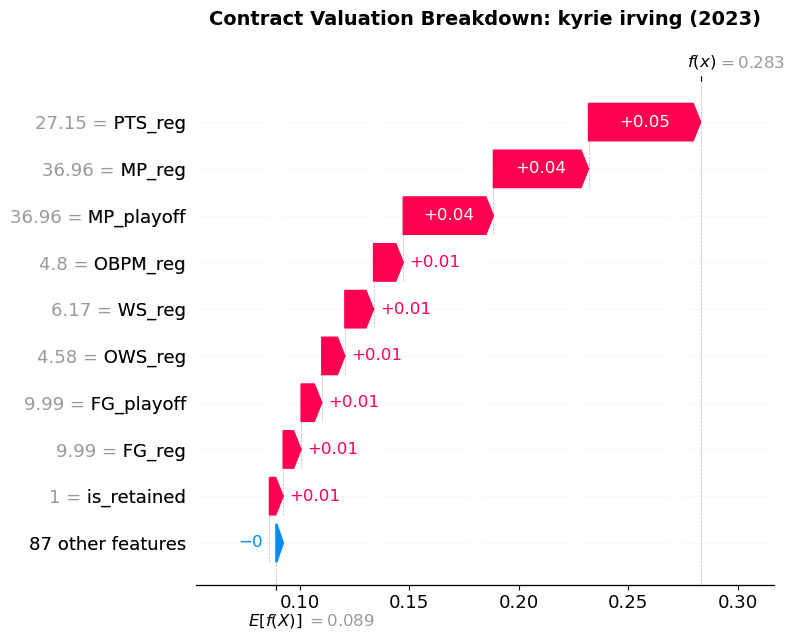

In [ ]:
"""
Model Training & SHAP Extraction Pipeline for NBA Salary Valuation
包含：XGBoost 減半網格調參、標準化 Logistic Regression、以及 SHAP 視覺化圖表匯出。
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import os
import logging

from xgboost import XGBRegressor
from sklearn.experimental import enable_halving_search_cv  # 必須引入才能使用 HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


def train_pricing_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
    使用 HalvingGridSearchCV 訓練並調參 XGBoost 定價模型
    """
    logger.info("開始 HalvingGridSearchCV 調參...")
    
    # 1. 初始化模型
    reg = XGBRegressor(enable_categorical=True, learning_rate=0.1, random_state=42)
    
    # 2. 設定參數網格
    param_grid = {
        "max_depth": [3, 5, 7, 9],            # 樹的深度
        "min_child_weight": [1, 5, 10],       # 節點分裂限制
        "subsample": [0.8, 1.0],              # 樣本隨機抽樣
        "colsample_bytree": [0.8, 1.0]        # 特徵隨機抽樣
    }
    
    # 3. 進行逐次減半網格搜索
    search = HalvingGridSearchCV(
        estimator=reg, 
        param_grid=param_grid, 
        resource='n_estimators', 
        min_resources=50,       
        max_resources=800,      
        factor=2,               
        cv=3,                   
        scoring='neg_root_mean_squared_error',  
        random_state=42,
        n_jobs=-1
    )
    
    # 訓練並尋找最佳參數
    search.fit(X_train, y_train)
    
    logger.info(f"🏆 最佳參數組合: {search.best_params_}")
    
    # 提取最強模型
    best_model = search.best_estimator_
    
    # 評估模型
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    logger.info(f"定價模型測試集表現 -> R2: {r2:.4f}, RMSE: {rmse:.4f}")
    return best_model


def train_duration_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
    使用 Pipeline (StandardScaler + LogisticRegression) 訓練年限模型
    """
    logger.info("開始訓練年限模型 (已加入 StandardScaler)...")
    
    # 建立管線，資料會先經過標準化，再進入分類器
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            multi_class='multinomial', 
            solver='lbfgs', 
            max_iter=1000, 
            random_state=42
        ))
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    logger.info(f"年限模型測試集表現 -> Accuracy: {acc:.4f}")
    return pipeline


def extract_pure_skill(model, X_test: pd.DataFrame, ids_test: pd.DataFrame, group_a: list, group_b: list):
    """
    使用 SHAP 剝離純實力與市場雜訊，回傳 SHAP 數值物件與分析表格。
    """
    logger.info("開始執行 SHAP 雜訊剝離...")
    
    # 使用新版 API，直接回傳 Explanation 物件，方便後續畫圖
    explainer = shap.TreeExplainer(model)
    shap_values_obj = explainer(X_test) 
    
    base_value = explainer.expected_value
    results = []
    
    for i in range(len(X_test)):
        player_name = ids_test.iloc[i]['Player']
        contract_year = ids_test.iloc[i]['year']
        
        # 這裡從 Explanation 物件中抽出純數值陣列來計算總和
        player_shap_vals = shap_values_obj.values[i]
        
        skill_impact = sum([player_shap_vals[X_test.columns.get_loc(f)] for f in group_a if f in X_test.columns])
        pure_skill_pct = base_value + skill_impact
        noise_impact = sum([player_shap_vals[X_test.columns.get_loc(f)] for f in group_b if f in X_test.columns])
        
        total_pred_pct = pure_skill_pct + noise_impact
        
        results.append({
            'Player': player_name,
            'Year': contract_year,
            'Base_Value': base_value,
            'Pure_Skill_Impact': skill_impact,
            'Pure_Skill_Valuation': pure_skill_pct,
            'Market_Noise_Impact': noise_impact,
            'Total_Predicted_Cap_Pct': total_pred_pct
        })
        
    results_df = pd.DataFrame(results)
    logger.info("SHAP 解析完成！")
    return explainer, shap_values_obj, results_df


def plot_player_shap_waterfall(shap_values_obj, X_test: pd.DataFrame, ids_test: pd.DataFrame, player_name: str, target_year: int, output_dir: str = '../../reports/figures'):
    """
    繪製並儲存特定球員的 SHAP 瀑布圖 (Waterfall Plot)
    """
    # 尋找該球員在測試集中的索引位置
    match_idx = np.where((ids_test['Player'] == player_name) & (ids_test['year'] == target_year))[0]
    
    if len(match_idx) == 0:
        logger.warning(f"圖表生成失敗：找不到 {player_name} 在 {target_year} 年的測試集資料。")
        return
    
    player_idx = match_idx[0]
    
    # 繪圖設定
    plt.figure(figsize=(10, 6))
    
    # 呼叫 SHAP 內建的瀑布圖，max_display 決定顯示幾個最關鍵的特徵
    shap.plots.waterfall(shap_values_obj[player_idx], max_display=10, show=False)
    
    plt.title(f"Contract Valuation Breakdown: {player_name} ({target_year})", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # 建立資料夾並存檔
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    safe_name = player_name.replace(" ", "_").lower()
    file_path = os.path.join(output_dir, f"shap_waterfall_{safe_name}_{target_year}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    logger.info(f"已儲存 {player_name} 的 SHAP 瀑布圖至: {file_path}")
    plt.show()

# --- 執行管線範例 ---
# 1. 訓練模型
best_pricing_model = train_pricing_model(X_train, y_pct_train, X_test, y_pct_test)
pipeline_duration_model = train_duration_model(X_train, y_yrs_train, X_test, y_yrs_test)

# 2. 執行 SHAP 解析
explainer, shap_values_obj, shap_results_df = extract_pure_skill(best_pricing_model, X_test, ids_test, group_a, group_b)

# 3. 畫出球星的價值拆解圖！
plot_player_shap_waterfall(shap_values_obj, X_test, ids_test, player_name='kyrie irving', target_year=2023)